In [129]:
#import thư viện 
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, models, datasets
from torchvision.utils import make_grid
from torchvision.datasets import ImageFolder
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import OneCycleLR
from collections import Counter

from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

**Exploring the data*** 

In [130]:
data_dir = "/kaggle/input/railway-track-fault-detection/Railway Track fault Detection Updated"  
train_dir = data_dir + "/Train" 
valid_dir = data_dir + "/Validation"
test_dir = data_dir + "/Test"  
classes = os.listdir(train_dir)
print(classes)  


['Defective', 'Non defective']


**Number of classes**

In [131]:
nums = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in classes}

In [132]:
#Print number of images in each dataset
print("No. of examples in train set:", len(os.listdir(train_dir + "/Defective")) + len(os.listdir(train_dir + "/Non defective")))

No. of examples in train set: 300


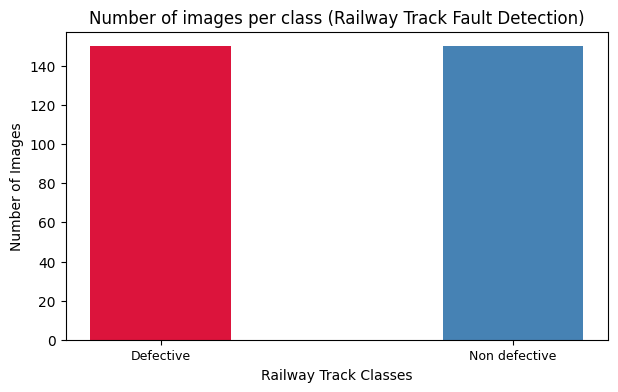

In [133]:
index = range(len(classes))

plt.figure(figsize=(7,4))
plt.bar(index, nums.values(), width=0.4, color=['crimson', 'steelblue'])
plt.xlabel('Railway Track Classes', fontsize=10)
plt.ylabel('Number of Images', fontsize=10)
plt.xticks(index, classes, fontsize=9)
plt.title('Number of images per class (Railway Track Fault Detection)')
plt.show()

**Data Preparation: Transforms and DataLoaders**

In [134]:
sizes = []

for cls in classes:
    folder = os.path.join(train_dir, cls)
    for filename in os.listdir(folder):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(folder, filename)
            with Image.open(path) as img:
                sizes.append(img.size)  # (width, height)

# Đếm tần suất từng kích thước
size_counts = Counter(sizes)

In [135]:
print("Kích thước ảnh (width x height) và số lượng:")
for size, count in size_counts.items():
    print(f"  {size}: {count} ảnh")

print("\nTổng số ảnh:", sum(size_counts.values()))
print("Số kích thước khác nhau:", len(size_counts))

Kích thước ảnh (width x height) và số lượng:
  (265, 190): 1 ảnh
  (4000, 3000): 249 ảnh
  (1408, 1407): 1 ảnh
  (960, 720): 6 ảnh
  (615, 461): 1 ảnh
  (960, 721): 4 ảnh
  (512, 384): 1 ảnh
  (480, 640): 2 ảnh
  (220, 165): 1 ảnh
  (194, 148): 1 ảnh
  (880, 657): 1 ảnh
  (156, 322): 1 ảnh
  (1024, 683): 2 ảnh
  (299, 168): 1 ảnh
  (8000, 6000): 5 ảnh
  (289, 175): 1 ảnh
  (1024, 677): 1 ảnh
  (300, 168): 1 ảnh
  (2047, 1535): 1 ảnh
  (275, 183): 3 ảnh
  (293, 520): 2 ảnh
  (168, 299): 1 ảnh
  (600, 450): 1 ảnh
  (730, 411): 1 ảnh
  (1023, 768): 1 ảnh
  (640, 480): 1 ảnh
  (251, 201): 1 ảnh
  (284, 177): 1 ảnh
  (1200, 675): 1 ảnh
  (200, 187): 1 ảnh
  (790, 444): 1 ảnh
  (1280, 720): 1 ảnh
  (666, 500): 1 ảnh
  (259, 195): 1 ảnh

Tổng số ảnh: 299
Số kích thước khác nhau: 34


In [136]:
# Giá trị mean & std theo ImageNet (chuẩn cho ResNet)
mean = [0.485, 0.456, 0.406] 
std = [0.229, 0.224, 0.225]

In [137]:
#Image Normalize và Augmentation
train_tfms = transforms.Compose([
    transforms.Resize((256, 256)),        # Cố định kích thước trước
    transforms.RandomCrop(224),           # Crop nhẹ để tạo biến thể
    transforms.RandomHorizontalFlip(),    # Lật ngang (an toàn)
    transforms.RandomVerticalFlip(),      # Lật dọc (an toàn với đường ray)
    transforms.RandomRotation(10),        # Xoay nhẹ
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

valid_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])
test_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])


In [138]:
#PyTorch datasets
train_ds = ImageFolder(train_dir, train_tfms)
valid_ds = ImageFolder(valid_dir, valid_tfms)
test_ds=ImageFolder(test_dir,test_tfms)

In [139]:
#Data loaders
batch_size = 32
train_dl = DataLoader(train_ds, batch_size, shuffle=True, num_workers=2, pin_memory=True)
valid_dl = DataLoader(valid_ds, batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size, shuffle=False, num_workers=2, pin_memory=True)

In [140]:
# for moving data into GPU (if available)
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available:
        return torch.device("cuda")
    else:
        return torch.device("cpu")

# for moving data to device (CPU or GPU)
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

# for loading in the device (GPU if available else CPU)
class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
        
    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)
        
    def __len__(self):
        """Number of batches"""
        return len(self.dl)

In [141]:
device = get_default_device()
device

device(type='cuda')

In [142]:
train_dl = DeviceDataLoader(train_dl, device)
valid_dl = DeviceDataLoader(valid_dl, device)
test_dl = DeviceDataLoader(test_dl, device)

In [143]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.should_stop = False

    def step(self, val_acc):
        if self.best_score is None:
            self.best_score = val_acc
            return

        # Nếu cải thiện nhỏ hơn min_delta → không tính là cải thiện
        if val_acc < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        else:
            self.best_score = val_acc
            self.counter = 0


In [144]:
def TestReport(title):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in test_dl:
            x, y = x.to(device), y.to(device)
            out = model(x)
            preds = out.argmax(1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(y.cpu().numpy())

    # Ghép kết quả
    y_pred = np.concatenate(all_preds) if len(all_preds) else np.array([])
    y_true = np.concatenate(all_labels) if len(all_labels) else np.array([])

    if y_true.size == 0:
        print(" TestReport: test_dl trống hoặc chưa được khởi tạo.")
        return None

    # Báo cáo
    print(f"=== 📊 Classification Report (Test set – {title}) ===")
    print(classification_report(
        y_true, y_pred,
        target_names=train_ds.classes,
        digits=3
    ))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=train_ds.classes, yticklabels=train_ds.classes)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.title(f"Confusion Matrix (Test set – {title})")
    plt.tight_layout()
    plt.show()

In [145]:
num_classes = len(train_ds.classes)

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes)
)
model = model.to(device)

In [146]:
full_train_loss = []
full_val_loss = []
full_train_acc = []
full_val_acc = []

In [ ]:
# --- PHASE 1: WARM UP HEAD (5 Epochs) ---
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

In [148]:
optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.01)

In [149]:
def run_epoch(dl, train=True):
    model.train(mode=train)
    total_loss, total_correct, total = 0.0, 0, 0
    for x,y in dl:
        x,y = x.to(device), y.to(device)
        if train: optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        if train:
            loss.backward()
            nn.utils.clip_grad_value_(model.parameters(), 0.1)
            optimizer.step()
        total_loss += loss.item() * x.size(0)
        total_correct += (out.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss/total, total_correct/total

In [150]:
for epoch in range(1, 6):
    tr_loss, tr_acc = run_epoch(train_dl, train=True)
    va_loss, va_acc = run_epoch(valid_dl, train=False)
    print(f"[P1-Epoch {epoch}/5] Train Loss: {tr_loss:.4f} |Train Acc: {tr_acc:.4f} | Val Loss: {va_loss:.3f} | Val Acc: {va_acc:.3f}")    
    full_train_loss.append(tr_loss)
    full_val_loss.append(va_loss)
    full_train_acc.append(tr_acc)
    full_val_acc.append(va_acc)

[P1-Epoch 1/5] Train Loss: 0.6875 |Train Acc: 0.5267 | Val Loss: 0.667 | Val Acc: 0.710
[P1-Epoch 2/5] Train Loss: 0.6554 |Train Acc: 0.6767 | Val Loss: 0.645 | Val Acc: 0.806
[P1-Epoch 3/5] Train Loss: 0.6232 |Train Acc: 0.8100 | Val Loss: 0.622 | Val Acc: 0.790
[P1-Epoch 4/5] Train Loss: 0.5970 |Train Acc: 0.7633 | Val Loss: 0.598 | Val Acc: 0.839
[P1-Epoch 5/5] Train Loss: 0.5838 |Train Acc: 0.7733 | Val Loss: 0.579 | Val Acc: 0.790


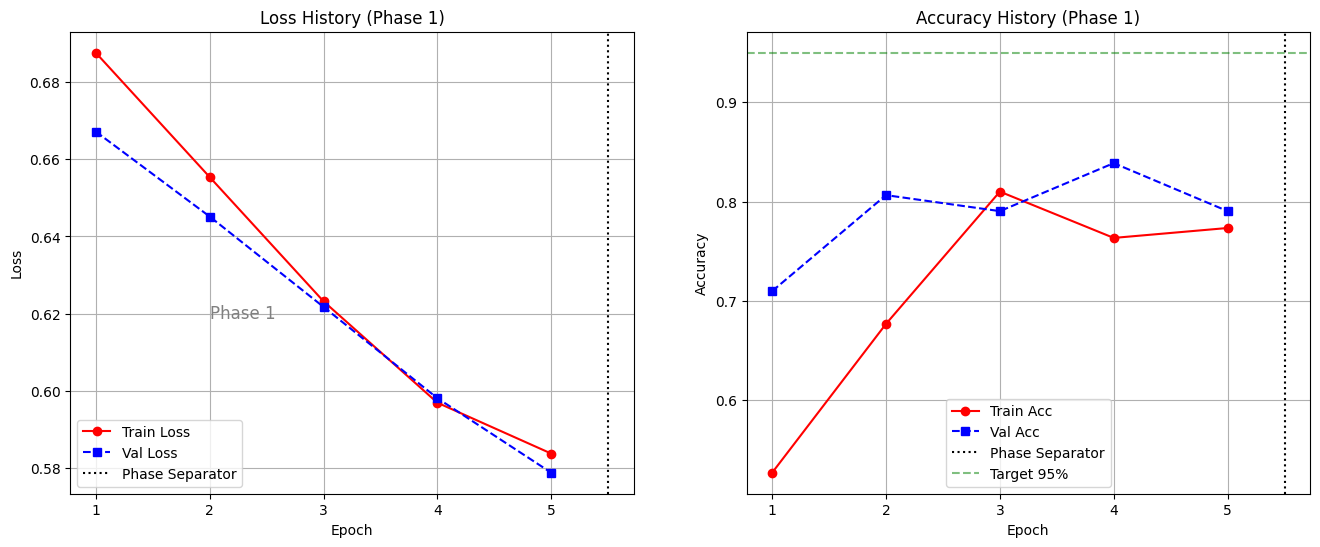

In [151]:
plt.figure(figsize=(16, 6))

# Tổng số epoch thực tế đã chạy
epochs = range(1, len(full_train_loss) + 1)

# 1. Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, full_train_loss, 'r-o', label='Train Loss')
plt.plot(epochs, full_val_loss, 'b--s', label='Val Loss')
# Vẽ đường thẳng đứng ngăn cách 2 phase
plt.axvline(x=5.5, color='k', linestyle=':', label='Phase Separator')
plt.text(2, max(full_train_loss)*0.9, 'Phase 1', fontsize=12, color='gray')
plt.title('Loss History (Phase 1)')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

# 2. Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, full_train_acc, 'r-o', label='Train Acc')
plt.plot(epochs, full_val_acc, 'b--s', label='Val Acc')
plt.axvline(x=5.5, color='k', linestyle=':', label='Phase Separator')
plt.axhline(y=0.95, color='green', linestyle='--', alpha=0.5, label='Target 95%')
plt.title('Accuracy History (Phase 1)')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)

plt.show()

PHASE 2

In [152]:
for param in model.parameters():
    param.requires_grad = True

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)

In [154]:
best_acc = 0.0
EPOCHS = 20
early_stop = EarlyStopping(patience=5, min_delta=1e-4)

In [155]:
full_train_loss = []
full_val_loss = []
full_train_acc = []
full_val_acc = []

In [156]:
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_dl, train=True)
    va_loss, va_acc = run_epoch(valid_dl, train=False)

    full_train_loss.append(tr_loss)
    full_val_loss.append(va_loss)
    full_train_acc.append(tr_acc)
    full_val_acc.append(va_acc)
    
    if va_acc > best_acc:
        best_acc = va_acc
        torch.save(model.state_dict(), "best_railway_model.pt")
        saved_msg = "★ SAVED"
    else:
        saved_msg = ""
        
    current_lr = optimizer.param_groups[0]['lr']
    print(f"[Epoch {epoch:02d}/{EPOCHS}] Train Loss: {tr_loss:.4f} |Train Acc: {tr_acc:.4f} | Val Loss: {va_loss:.3f} | Val Acc: {va_acc:.3f} | LR: {current_lr:.1e} {saved_msg}")

    scheduler.step(va_acc)

    early_stop.step(va_acc)
    if early_stop.should_stop:
        print(f"=== EARLY STOPPING tại epoch {epoch} (không cải thiện {early_stop.patience} epoch) ===")
        break

print(f"Train xong! Best Val Acc: {best_acc:.3f}")

[Epoch 01/20] Train Loss: 0.5118 |Train Acc: 0.8000 | Val Loss: 0.433 | Val Acc: 0.855 | LR: 1.0e-04 ★ SAVED
[Epoch 02/20] Train Loss: 0.3938 |Train Acc: 0.8600 | Val Loss: 0.376 | Val Acc: 0.871 | LR: 1.0e-04 ★ SAVED
[Epoch 03/20] Train Loss: 0.3036 |Train Acc: 0.8767 | Val Loss: 0.302 | Val Acc: 0.919 | LR: 1.0e-04 ★ SAVED
[Epoch 04/20] Train Loss: 0.2442 |Train Acc: 0.9233 | Val Loss: 0.285 | Val Acc: 0.935 | LR: 1.0e-04 ★ SAVED
[Epoch 05/20] Train Loss: 0.1609 |Train Acc: 0.9567 | Val Loss: 0.293 | Val Acc: 0.887 | LR: 1.0e-04 
[Epoch 06/20] Train Loss: 0.1141 |Train Acc: 0.9700 | Val Loss: 0.280 | Val Acc: 0.935 | LR: 1.0e-04 
[Epoch 07/20] Train Loss: 0.0973 |Train Acc: 0.9800 | Val Loss: 0.278 | Val Acc: 0.952 | LR: 1.0e-04 ★ SAVED
[Epoch 08/20] Train Loss: 0.0772 |Train Acc: 0.9867 | Val Loss: 0.297 | Val Acc: 0.919 | LR: 1.0e-04 
[Epoch 09/20] Train Loss: 0.0712 |Train Acc: 0.9833 | Val Loss: 0.351 | Val Acc: 0.935 | LR: 1.0e-04 
[Epoch 10/20] Train Loss: 0.0767 |Train Acc: 0.

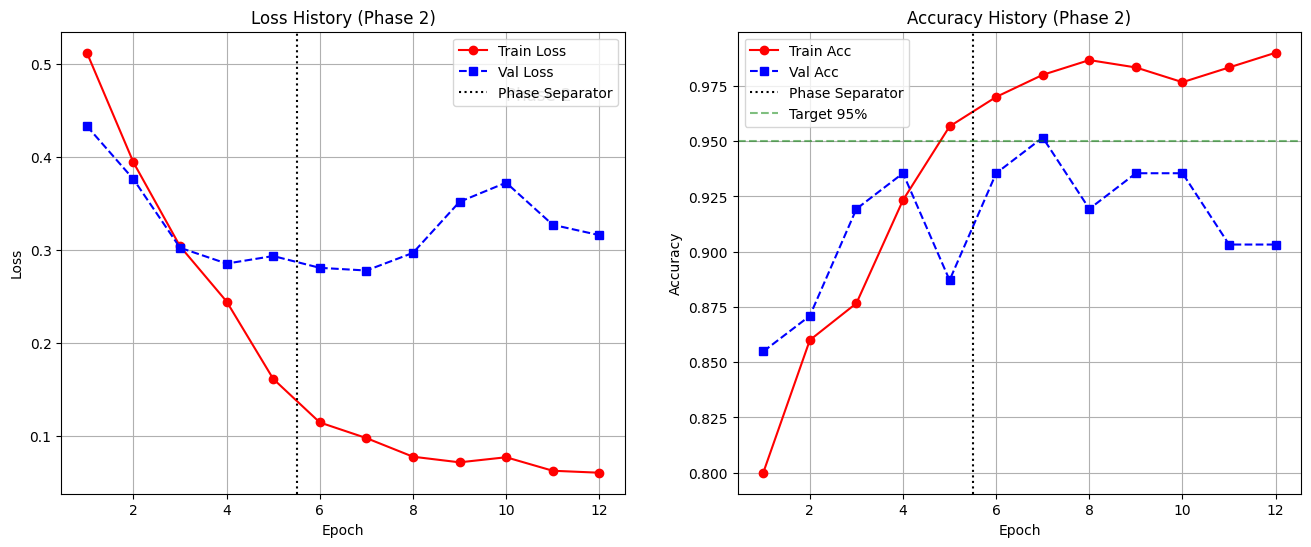

In [157]:
plt.figure(figsize=(16, 6))

# Tổng số epoch thực tế đã chạy
epochs = range(1, len(full_train_loss) + 1)

# 1. Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, full_train_loss, 'r-o', label='Train Loss')
plt.plot(epochs, full_val_loss, 'b--s', label='Val Loss')
# Vẽ đường thẳng đứng ngăn cách 2 phase
plt.axvline(x=5.5, color='k', linestyle=':', label='Phase Separator')
plt.text(10, max(full_train_loss)*0.9, 'Phase 2', fontsize=12, color='gray')
plt.title('Loss History (Phase 2)')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

# 2. Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, full_train_acc, 'r-o', label='Train Acc')
plt.plot(epochs, full_val_acc, 'b--s', label='Val Acc')
plt.axvline(x=5.5, color='k', linestyle=':', label='Phase Separator')
plt.axhline(y=0.95, color='green', linestyle='--', alpha=0.5, label='Target 95%')
plt.title('Accuracy History (Phase 2)')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)

plt.show()

=== 📊 Classification Report (Test set – Final Result) ===
               precision    recall  f1-score   support

    Defective      1.000     0.909     0.952        11
Non defective      0.917     1.000     0.957        11

     accuracy                          0.955        22
    macro avg      0.958     0.955     0.954        22
 weighted avg      0.958     0.955     0.954        22



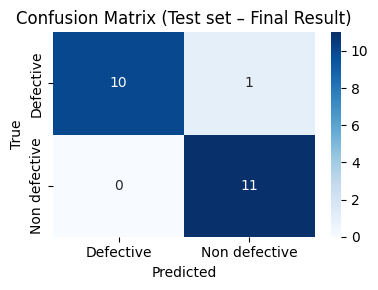

In [158]:
# Load lại best model để test
model.load_state_dict(torch.load("best_railway_model.pt"))
TestReport("Final Result")

In [159]:
import torch
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import os

# Mean & Std theo ImageNet
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

# Transform dùng để dự đoán
predict_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

def predict_railway_fault(image_path, model):
    """
    Hiển thị ảnh + dự đoán class + xác suất Softmax.
    """
    model.eval()

    if not os.path.exists(image_path):
        print("Lỗi: File ảnh không tồn tại.")
        return

    # Load ảnh
    img = Image.open(image_path).convert("RGB")

    # Preprocess
    x = predict_tfms(img)
    x = x.unsqueeze(0).to(next(model.parameters()).device)

    # Forward
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred  = np.argmax(probs)

    # Class label (đúng với dataset Railway Track)
    classes = ["Defective", "Non defective"]

    # Hiển thị ảnh
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Dự đoán: {classes[pred]}  |  Độ tin cậy: {probs[pred]:.4f}")
    plt.show()

    
    return classes[pred], probs


Đang mở ảnh: /kaggle/input/railway-track-fault-detection/Railway Track fault Detection Updated/Test/Defective/IMG_20201114_100159.jpg
Đang phân tích...


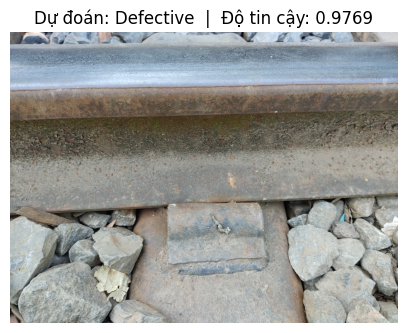

In [160]:
import os

# ==============================================================================
# 👇 BẠN HÃY DÁN ĐƯỜNG DẪN ẢNH VÀO GIỮA 2 DẤU NGOẶC KÉP BÊN DƯỚI 👇
# ==============================================================================

duong_dan_anh = "/kaggle/input/railway-track-fault-detection/Railway Track fault Detection Updated/Test/Defective/IMG_20201114_100159.jpg" 
# Ví dụ mẫu (xóa dòng trên và paste đường dẫn của bạn vào):
# duong_dan_anh = "/kaggle/input/..."

# ==============================================================================

# Kiểm tra xem file có tồn tại không trước khi chạy
if os.path.exists(duong_dan_anh):
    print(f"Đang mở ảnh: {duong_dan_anh}")
    print("Đang phân tích...")
    
    # Gọi hàm dự đoán (đã định nghĩa ở bước trước)
    predict_railway_fault(duong_dan_anh, model)
    
else:
    print("LỖI: Không tìm thấy file ảnh!")
    print(f"Đường dẫn bạn nhập là: {duong_dan_anh}")
    print("Hãy kiểm tra kỹ lại đường dẫn (đừng quên dấu / ở đầu).")
    
    # Gợi ý: Liệt kê thử một vài ảnh có sẵn để bạn copy cho dễ
    try:
        sample_dir = "/kaggle/input/Railway Track fault Detection Updated/Test/Defective"
        if os.path.exists(sample_dir):
            print("Gợi ý một số ảnh có sẵn trong thư mục Test (bạn có thể copy tên này):")
            files = os.listdir(sample_dir)[:3] # Lấy 3 ảnh đầu tiên
            for f in files:
                print(f"   {os.path.join(sample_dir, f)}")
    except:
        pass